# Notebook 01 — Exploratory Data Analysis (EDA) - Data Quality & Return Characteristics (FTSE 100)

## Purpose
This notebook performs exploratory data analysis (EDA) for the MSc research project:

**Research question (context):**  
Under what market conditions do machine learning models fail to improve a simple momentum strategy when decision stability and turnover are considered?

## Data & Experimental Setup
- **Universe:** FTSE 100 constituents (from LSEG list)
- **Price source:** Yahoo Finance via `yfinance`
- **Frequency:** Monthly (returns aggregated from daily Adjusted Close prices)
- **Train/Test split:**  
  - Train: **2015–2024**  
  - Test (hold-out): **2025**

## Outputs of this notebook
- Basic data quality checks (shapes, coverage, missingness)
- Return distribution checks (pooled, extremes)
- Time variation checks (dispersion and volatility proxy)
- Figures saved to: `reports/figures/eda/`

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load datasets

Load:
- Daily **Adjusted Close** prices (raw)
- Monthly returns (processed)
- Pre-defined train/test splits

These are produced by the reproducible pipeline (`src/run_pipeline.py`).

In [2]:
RAW_ADJ_CLOSE_PATH = "../data/raw/adj_close_2015_2025.parquet"
RET_MONTHLY_PATH = "../data/processed/returns_monthly.parquet"
TRAIN_PATH = "../data/processed/train_monthly_2015_2024.parquet"
TEST_PATH = "../data/processed/test_monthly_2025.parquet"

adj_close = pd.read_parquet(RAW_ADJ_CLOSE_PATH)
returns_monthly = pd.read_parquet(RET_MONTHLY_PATH)
train_monthly = pd.read_parquet(TRAIN_PATH)
test_monthly = pd.read_parquet(TEST_PATH)

print("Loaded datasets:")
print("adj_close (daily):", adj_close.shape)
print("returns_monthly:", returns_monthly.shape)
print("train_monthly:", train_monthly.shape)
print("test_monthly:", test_monthly.shape)

Loaded datasets:
adj_close (daily): (2778, 100)
returns_monthly: (132, 100)
train_monthly: (120, 100)
test_monthly: (12, 100)


## 2. Basic dataset overview

Confirm:
- Date ranges
- Number of tickers
- Example tickers (naming format)

In [3]:
def describe_panel(df: pd.DataFrame, name: str):
    print(f"\n{name}")
    print("-" * len(name))
    print("Rows (dates):", df.shape[0])
    print("Cols (tickers):", df.shape[1])
    print("Date range:", df.index.min(), "->", df.index.max())
    print("Example tickers:", list(df.columns[:10]))

describe_panel(adj_close, "RAW Adj Close (Daily)")
describe_panel(returns_monthly, "Monthly Returns (All)")
describe_panel(train_monthly, "Monthly Returns (Train 2015–2024)")
describe_panel(test_monthly, "Monthly Returns (Test 2025)")


RAW Adj Close (Daily)
---------------------
Rows (dates): 2778
Cols (tickers): 100
Date range: 2015-01-02 00:00:00 -> 2025-12-30 00:00:00
Example tickers: ['AAF.L', 'AAL.L', 'ABF.L', 'ADM.L', 'ALW.L', 'ANTO.L', 'AUTO.L', 'AV.L', 'AZN.L', 'BA.L']

Monthly Returns (All)
---------------------
Rows (dates): 132
Cols (tickers): 100
Date range: 2015-01-31 00:00:00 -> 2025-12-31 00:00:00
Example tickers: ['AAF.L', 'AAL.L', 'ABF.L', 'ADM.L', 'ALW.L', 'ANTO.L', 'AUTO.L', 'AV.L', 'AZN.L', 'BA.L']

Monthly Returns (Train 2015–2024)
---------------------------------
Rows (dates): 120
Cols (tickers): 100
Date range: 2015-01-31 00:00:00 -> 2024-12-31 00:00:00
Example tickers: ['AAF.L', 'AAL.L', 'ABF.L', 'ADM.L', 'ALW.L', 'ANTO.L', 'AUTO.L', 'AV.L', 'AZN.L', 'BA.L']

Monthly Returns (Test 2025)
---------------------------
Rows (dates): 12
Cols (tickers): 100
Date range: 2025-01-31 00:00:00 -> 2025-12-31 00:00:00
Example tickers: ['AAF.L', 'AAL.L', 'ABF.L', 'ADM.L', 'ALW.L', 'ANTO.L', 'AUTO.L', 'AV.L

## 3. Missing data inspection (daily prices)

Daily price missingness can occur due to:
- listing changes or index membership changes
- ticker renames
- incomplete history on Yahoo Finance

This is primarily a transparency check.  
Our modelling is monthly, so the monthly missingness is more relevant.

In [4]:
missing_daily = adj_close.isna().mean().sort_values(ascending=False)

print("Daily missing ratio (top 15):")
display(missing_daily.head(15))

print("\nSummary:")
print("Tickers with >10% daily missing:", int((missing_daily > 0.10).sum()))
print("Tickers with 100% daily missing:", int((missing_daily == 1.0).sum()))

Daily missing ratio (top 15):


Ticker
MTLN.L    0.962563
HLN.L     0.685745
MNG.L     0.437005
AAF.L     0.408207
CCEP.L    0.385889
EDV.L     0.280058
PSH.L     0.199424
CTEC.L    0.165947
AUTO.L    0.019438
IAG.L     0.001800
GLEN.L    0.000720
CRDA.L    0.000360
IMB.L     0.000360
RIO.L     0.000360
BP.L      0.000360
dtype: float64


Summary:
Tickers with >10% daily missing: 8
Tickers with 100% daily missing: 0


## 4. Missing data inspection (monthly returns)

Monthly missingness is more relevant for:
- strategy backtesting (monthly rebalance)
- ML dataset generation (monthly features & targets)

In [5]:
missing_monthly = returns_monthly.isna().mean().sort_values(ascending=False)

print("Monthly missing ratio (top 15):")
display(missing_monthly.head(15))

print("\nSummary:")
print("Tickers with >10% monthly missing:", int((missing_monthly > 0.10).sum()))
print("Tickers with 100% monthly missing:", int((missing_monthly == 1.0).sum()))

Monthly missing ratio (top 15):


Ticker
AAF.L     0.0
AAL.L     0.0
ABF.L     0.0
ADM.L     0.0
ALW.L     0.0
ANTO.L    0.0
AUTO.L    0.0
AV.L      0.0
AZN.L     0.0
BA.L      0.0
BAB.L     0.0
BARC.L    0.0
BATS.L    0.0
BBOX.L    0.0
BEZ.L     0.0
dtype: float64


Summary:
Tickers with >10% monthly missing: 0
Tickers with 100% monthly missing: 0


## 5. Pooled distribution of monthly returns

Pool all tickers and months to examine:
- typical return magnitude
- heavy tails and outliers
- whether values look realistic (sanity check)

Monthly returns pooled distribution:


count    13200.000000
mean         0.004102
std          0.079844
min         -0.827908
1%          -0.216997
5%          -0.117269
50%          0.003767
95%          0.119561
99%          0.204126
max          0.608806
dtype: float64

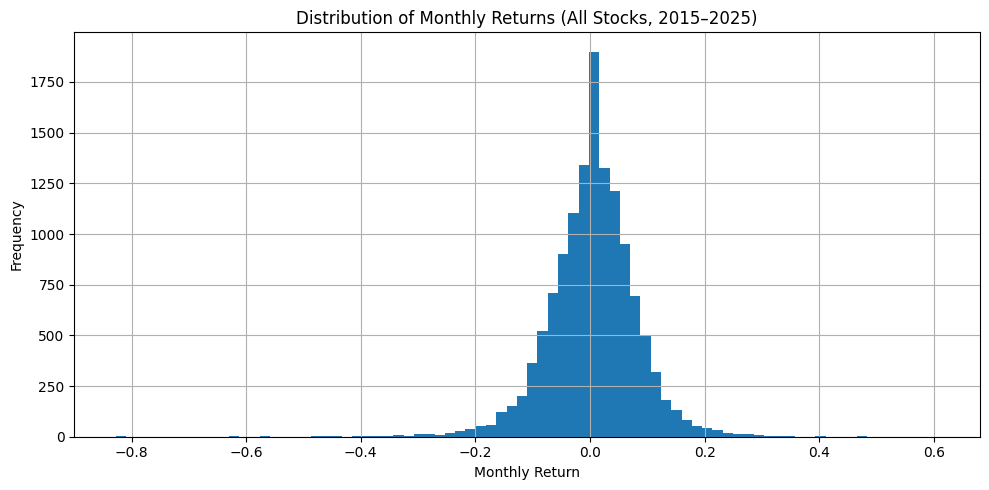

In [6]:
r_all = returns_monthly.stack().dropna()

print("Monthly returns pooled distribution:")
display(r_all.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

plt.figure(figsize=(10, 5))
plt.hist(r_all, bins=80)
plt.title("Distribution of Monthly Returns (All Stocks, 2015–2025)")
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Extreme monthly returns (sanity check)

We inspect the largest positive and negative monthly returns across all tickers.

This helps validate:
- crash months and rebound months are plausible
- no data processing bugs created unrealistic returns

In [7]:
top_pos = r_all.sort_values(ascending=False).head(10)
top_neg = r_all.sort_values(ascending=True).head(10)

print("Top 10 positive monthly returns (date, ticker -> return):")
display(top_pos)

print("Top 10 negative monthly returns (date, ticker -> return):")
display(top_neg)

Top 10 positive monthly returns (date, ticker -> return):


Date        Ticker
2020-06-30  AAF.L     0.608806
2016-02-29  AAL.L     0.548666
2016-06-30  FRES.L    0.488173
2016-07-31  MRO.L     0.474836
2020-11-30  IAG.L     0.469329
2020-10-31  RR.L      0.469178
2020-11-30  EZJ.L     0.465198
            BAB.L     0.441931
2023-01-31  EZJ.L     0.415682
2016-02-29  GLEN.L    0.398212
dtype: float64

Top 10 negative monthly returns (date, ticker -> return):


Date        Ticker
2020-03-31  MRO.L    -0.827908
2020-09-30  IAG.L    -0.822579
2020-03-31  IAG.L    -0.785876
            EZJ.L    -0.656131
            CNA.L    -0.638642
2021-06-30  EDV.L    -0.620230
2020-09-30  RR.L     -0.617678
2020-03-31  RR.L     -0.599011
            WEIR.L   -0.593702
            ICG.L    -0.574248
dtype: float64

## 7. Cross-sectional dispersion over time

We compute each month:
- cross-sectional mean return across tickers
- cross-sectional standard deviation (dispersion)

Dispersion is useful because:
- cross-sectional strategies depend on differences between stocks
- model behaviour can change when dispersion is high vs low

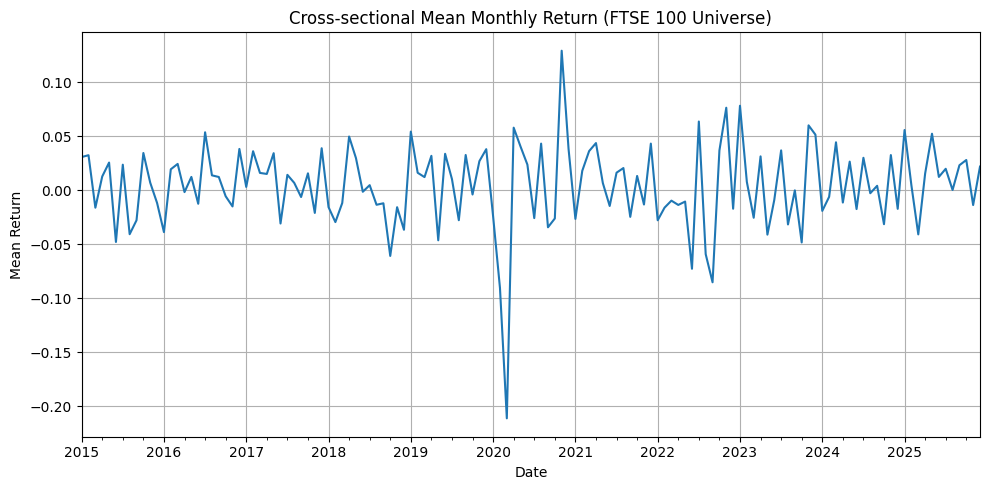

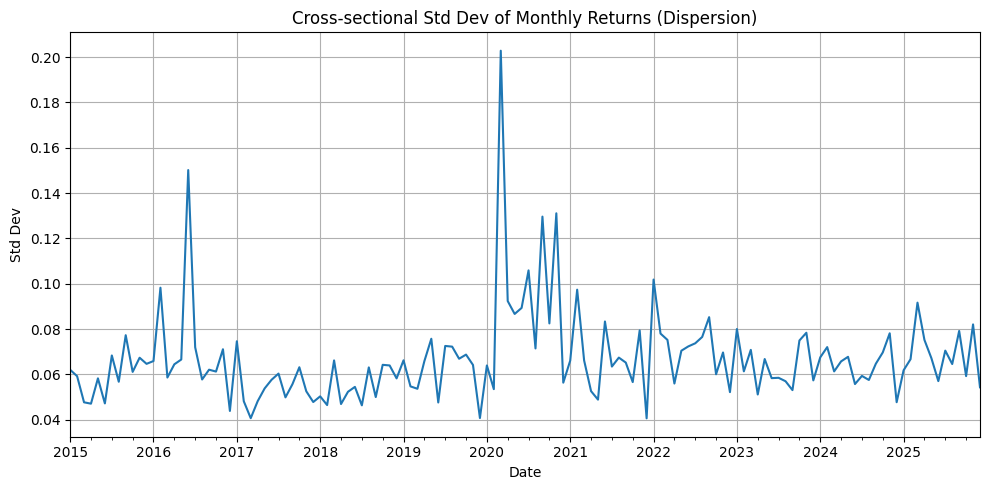

In [8]:
cs_mean = returns_monthly.mean(axis=1)
cs_std = returns_monthly.std(axis=1)

plt.figure(figsize=(10, 5))
cs_mean.plot()
plt.title("Cross-sectional Mean Monthly Return (FTSE 100 Universe)")
plt.xlabel("Date")
plt.ylabel("Mean Return")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
cs_std.plot()
plt.title("Cross-sectional Std Dev of Monthly Returns (Dispersion)")
plt.xlabel("Date")
plt.ylabel("Std Dev")
plt.grid(True)
plt.tight_layout()
plt.show()

## 8. Volatility proxy (regime intuition)

Compute:
- average monthly return across stocks (equal-weight mean)
- rolling 12-month volatility of that series

This is a simple proxy for different market conditions (regimes).

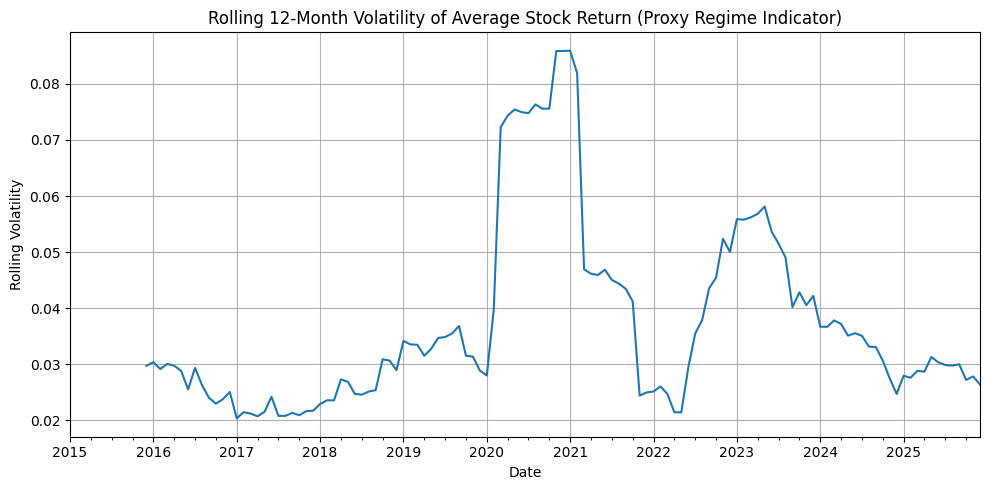

In [9]:
avg_return = returns_monthly.mean(axis=1)
rolling_vol_12 = avg_return.rolling(12).std()

plt.figure(figsize=(10, 5))
rolling_vol_12.plot()
plt.title("Rolling 12-Month Volatility of Average Stock Return (Proxy Regime Indicator)")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.grid(True)
plt.tight_layout()
plt.show()

## 9. Train vs Test distribution comparison

Compare distributions between:
- Train (2015–2024)
- Test (2025)

This helps contextualise whether 2025 appears unusually volatile/calm.

,Train (2015–2024),Test (2025)
count,12000.000000,1200.000000
mean,0.003016,0.014961
std,0.080321,0.074061
min,-0.827908,-0.341531
1%,-0.219135,-0.186014
5%,-0.119177,-0.099425
50%,0.002644,0.013854
95%,0.118739,0.132839
99%,0.203301,0.204171
max,0.608806,0.357918


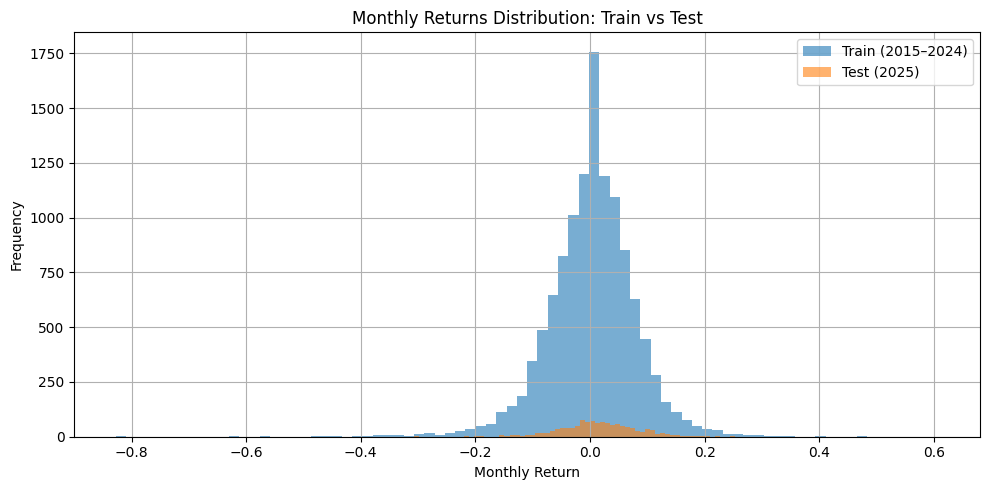

In [10]:
train_r = train_monthly.stack().dropna()
test_r = test_monthly.stack().dropna()

summary = pd.DataFrame({
    "Train (2015–2024)": train_r.describe(percentiles=[0.01,0.05,0.5,0.95,0.99]),
    "Test (2025)": test_r.describe(percentiles=[0.01,0.05,0.5,0.95,0.99]),
})

display(summary)

plt.figure(figsize=(10, 5))
plt.hist(train_r, bins=80, alpha=0.6, label="Train (2015–2024)")
plt.hist(test_r, bins=80, alpha=0.6, label="Test (2025)")
plt.title("Monthly Returns Distribution: Train vs Test")
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Save report-ready figures

Save key plots to `reports/figures/eda/` for inclusion in the final report.

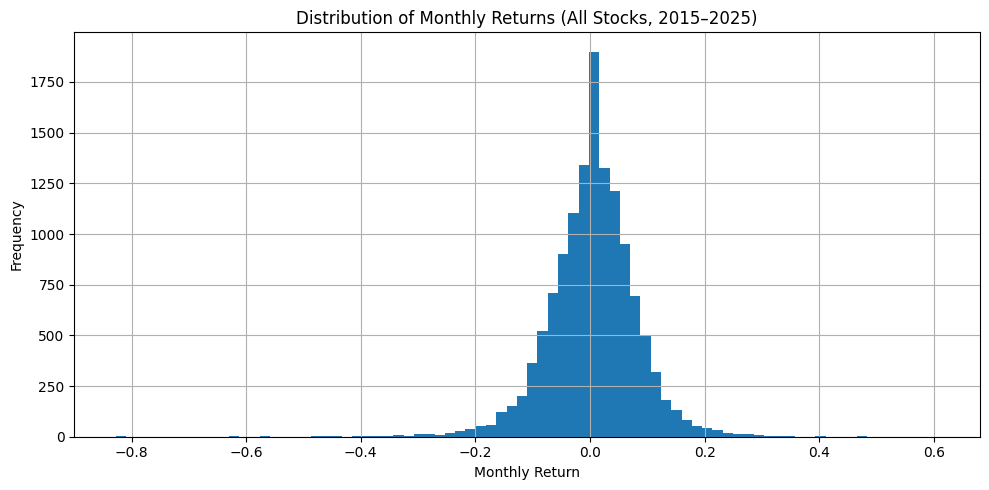

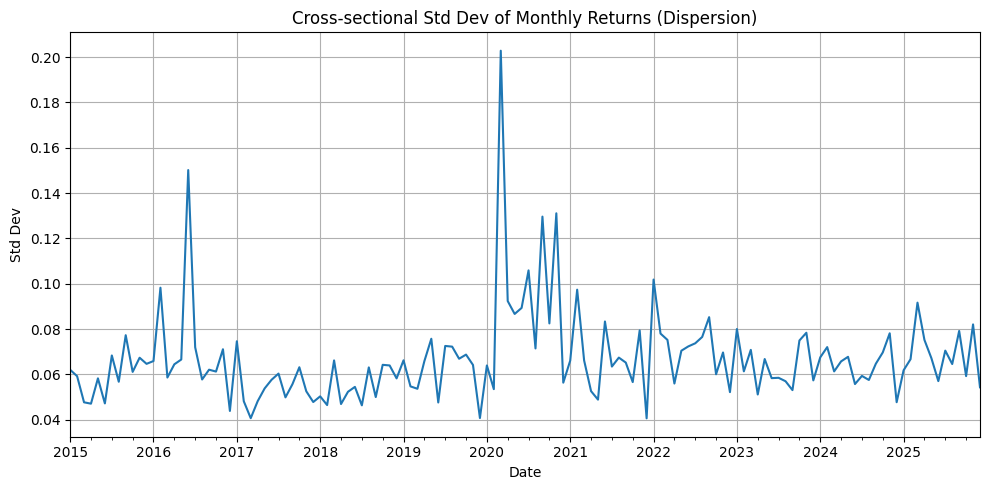

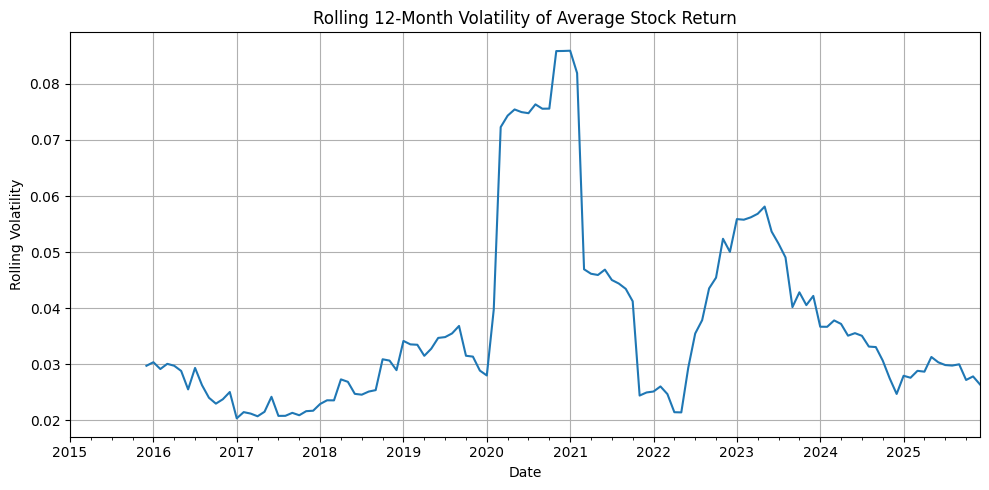

Saved figures to: reports/figures/eda


In [11]:
OUT_DIR = "reports/figures/eda"
os.makedirs(OUT_DIR, exist_ok=True)

# 1) Monthly return distribution
plt.figure(figsize=(10, 5))
plt.hist(r_all, bins=80)
plt.title("Distribution of Monthly Returns (All Stocks, 2015–2025)")
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "monthly_returns_distribution.png"), dpi=200)
plt.show()

# 2) Cross-sectional dispersion
plt.figure(figsize=(10, 5))
cs_std.plot()
plt.title("Cross-sectional Std Dev of Monthly Returns (Dispersion)")
plt.xlabel("Date")
plt.ylabel("Std Dev")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cross_sectional_dispersion.png"), dpi=200)
plt.show()

# 3) Rolling volatility proxy
plt.figure(figsize=(10, 5))
rolling_vol_12.plot()
plt.title("Rolling 12-Month Volatility of Average Stock Return")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "rolling_volatility_proxy.png"), dpi=200)
plt.show()

print("Saved figures to:", OUT_DIR)

## 11. EDA summary

Key checks completed:
- Confirmed data shapes, tickers, and date coverage (2015–2025)
- Reported daily vs monthly missingness
- Verified monthly return magnitudes and extreme values
- Visualised dispersion and a volatility proxy (regime intuition)
- Compared train vs test return distributions

Next:
- **Feature EDA** (ret windows, volatility, RSI)
- Baseline vs ML result plots (equity curve, drawdowns, turnover)